<a href="https://colab.research.google.com/github/chandradip01/ECG_SIGNAL_1DConv_model/blob/main/ECG_SIGNAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTINTG LIBARIES

In [70]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers , models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

DIVIDING DATA TRAIN AND TEST  and Printing the first 5 sample out of the data

In [71]:
df = pd.read_csv('/content/mitbih_test.csv', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,0.030992,0.028926,0.035124,0.026860,0.039256,0.035124,0.043388,0.047521,0.053719,0.053719,0.070248,0.072314,0.084711,0.097107,0.121901,0.132231,0.169421,0.196281,0.214876,0.235537,0.254132,0.264463,0.285124,0.272727,0.266529,0.239669,0.214876,0.173554,0.157025,0.123967,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,0.304029,0.336996,0.377289,0.391941,0.439560,0.446886,0.457875,0.479853,0.512821,0.534799,0.586081,0.586081,0.604396,0.633700,0.615385,0.582418,0.564103,0.520147,0.490842,0.490842,0.468864,0.454212,0.450549,0.465201,0.450549,0.432234,0.424908,0.410256,0.391941,0.369963,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,0.106195,0.141593,0.128319,0.150442,0.132743,0.150442,0.132743,0.150442,0.123894,0.163717,0.137168,0.141593,0.132743,0.150442,0.128319,0.146018,0.119469,0.123894,0.101770,0.092920,0.070796,0.079646,0.066372,0.070796,0.079646,0.092920,0.088496,0.084071,0.079646,0.088496,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,0.102083,0.122917,0.150000,0.168750,0.172917,0.170833,0.168750,0.164583,0.156250,0.152083,0.147917,0.147917,0.145833,0.145833,0.141667,0.141667,0.147917,0.158333,0.168750,0.179167,0.191667,0.206250,0.220833,0.239583,0.258333,0.275000,0.287500,0.308333,0.320833,0.331250,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,0.080537,0.104027,0.093960,0.117450,0.097315,0.134228,0.124161,0.161074,0.171141,0.194631,0.204698,0.261745,0.275168,0.332215,0.345638,0.395973,0.406040,0.456376,0.446309,0.446309,0.399329,0.369128,0.308725,0.295302,0.265101,0.271812,0.258389,0.268456,0.261745,0.281879,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
X = df.iloc[:, :-1].values  # All columns except last (Inputs)
y = df.iloc[:, -1].values   # Just the last column (Labels)

Spliting the dataset in to train test split

In [73]:
x_train , x_test , y_train , y_test = train_test_split(X , y , test_size=0.20 , random_state=42, stratify=y )

Reshape input features to 3D tensor:


In [74]:
x_train = np.expand_dims(x_train, axis=-1)

x_test = np.expand_dims(x_test, axis=-1)
x_train.shape
x_test.shape

(4379, 187, 1)

In [75]:
# 5. Handle heavy class imbalance
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

 1D CONVOLUTION NEURAL NETWORK ARCHITECTURE MODEL

In [76]:
model = models.Sequential([
    # Input Layer (
    layers.Input(shape=(187, 1)),

    # Block 1
    layers.Conv1D(filters=32, kernel_size=5, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool1D(pool_size=2),

    # Block 2
    layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool1D(pool_size=2),

    # Block 3
    layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool1D(pool_size=2),

    # Classification Head
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 183, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 87, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 87, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 41, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 41, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,677 (174.52 KB)

 Trainable params: 44,229 (172.77 KB)

 Non-trainable params: 448 (1.75 KB)

Compiling the Model

In [77]:
x_train = x_train.reshape(-1, 187, 1)
x_test = x_test.reshape(-1, 187, 1)

# 2. Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use 'categorical_crossentropy' if y is one-hot
    metrics=['accuracy']
)

Training the Model

In [78]:


# 4. Train model
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_test, y_test),
    class_weight=clean_class_weights
)

Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.4819 - loss: 0.9190 - val_accuracy: 0.0662 - val_loss: 3.4789
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.6602 - loss: 0.6079 - val_accuracy: 0.0886 - val_loss: 3.3531
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7229 - loss: 0.5100 - val_accuracy: 0.4019 - val_loss: 1.2415
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7643 - loss: 0.4505 - val_accuracy: 0.8456 - val_loss: 0.4870
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.7871 - loss: 0.4107 - val_accuracy: 0.8253 - val_loss: 0.4826
Epoch 6/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7999 - loss: 0.3972 - val_accuracy: 0.8771 - val_loss: 0.4514
Epoch 7/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.8116 - loss: 0.3568 - val_accuracy: 0.8717 - val_loss: 0.3900
Epoch 8/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.8224 - loss: 0.3387 - 

ACCURACY OF THE MODEL

In [79]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")


Final Test Accuracy: 81.94%


In [80]:
 disease_map = {
    0: "Normal Heartbeat",
    1: "Supraventricular Ectopic (Atrial Premature Beat)",
    2: "Ventricular Ectopic (Premature Ventricular Contraction)",
    3: "Fusion Beat",
    4: "Unknown / Pacemaker Beat"
}

# Print sample predictions using actual disease names
y_pred_prob = model.predict(x_test[:5])
y_pred_classes = np.argmax(y_pred_prob, axis=1)

print("--- Sample Predictions with Medical Disease Names ---")
for i in range(5):
    pred_disease = disease_map[y_pred_classes[i]]
    actual_disease = disease_map[y_test[i]]
    print(f"Sample #{i+1} -> Predicted: {pred_disease} | Actual: {actual_disease}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
--- Sample Predictions with Medical Disease Names ---
Sample #1 -> Predicted: Supraventricular Ectopic (Atrial Premature Beat) | Actual: Supraventricular Ectopic (Atrial Premature Beat)
Sample #2 -> Predicted: Normal Heartbeat | Actual: Normal Heartbeat
Sample #3 -> Predicted: Unknown / Pacemaker Beat | Actual: Unknown / Pacemaker Beat
Sample #4 -> Predicted: Normal Heartbeat | Actual: Normal Heartbeat
Sample #5 -> Predicted: Ventricular Ectopic (Premature Ventricular Contraction) | Actual: Ventricular Ectopic (Premature Ventricular Contraction)


Accuracy Curve

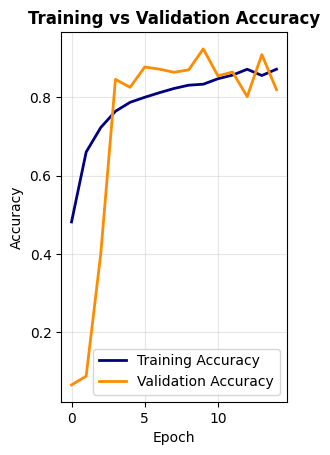

In [81]:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='navy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='darkorange')
plt.title('Training vs Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

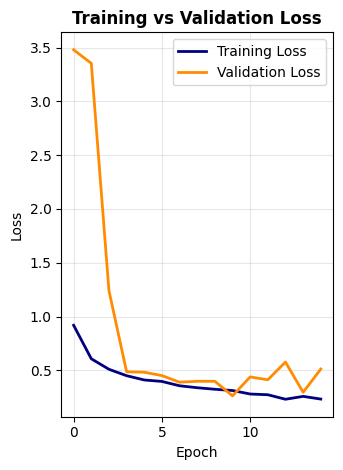

In [82]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2, color='navy')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='darkorange')
plt.title('Training vs Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()